In [13]:
# # !pip install keras tensorflow jax torch networkx matplotlib pandas
# import os

# # Choose backend: "jax", "torch", or "tensorflow"
# os.environ["KERAS_BACKEND"] = "tensorflow"
# import pandas as pd
# import numpy as np
# import networkx as nx
# import matplotlib

# # matplotlib.use("Agg")  # Use non-interactive backend
# import matplotlib.pyplot as plt
# import keras
# from keras import layers, ops

# keras.utils.set_random_seed(42)
# rng = np.random.default_rng(42)


In [14]:
# !pip install keras tensorflow jax torch networkx matplotlib pandas
import pandas as pd 
import numpy as np
from tensorflow.keras import utils as np_utils

In [15]:
dataset = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data", header=None)
X = dataset.iloc[:, :-1].values
Y = dataset.iloc[:, -1].values

print(dataset.head())

     0    1    2    3            4
0  5.1  3.5  1.4  0.2  Iris-setosa
1  4.9  3.0  1.4  0.2  Iris-setosa
2  4.7  3.2  1.3  0.2  Iris-setosa
3  4.6  3.1  1.5  0.2  Iris-setosa
4  5.0  3.6  1.4  0.2  Iris-setosa


In [16]:
dataset

,0,1,2,3,4
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [17]:
#here we need to do the label encoding so that when in the input neuron the output is in the form of 0,1,2 instead of the string values. So we will use the label encoder from sklearn to do that.
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
Y = encoder.fit_transform(Y)
Y= pd.get_dummies(Y).values


#now we need to spilit into the train test split 
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=0)

In [18]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)
Y

(120, 4) (30, 4) (120, 3) (30, 3)


array([[ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ T

Error in callback <function _draw_all_if_interactive at 0x7745bbf35da0> (for post_execute), with arguments args (),kwargs {}:


ValueError: Invalid RGBA argument: 'h'

ValueError: Invalid RGBA argument: 'h'

<Figure size 400x100 with 1 Axes>

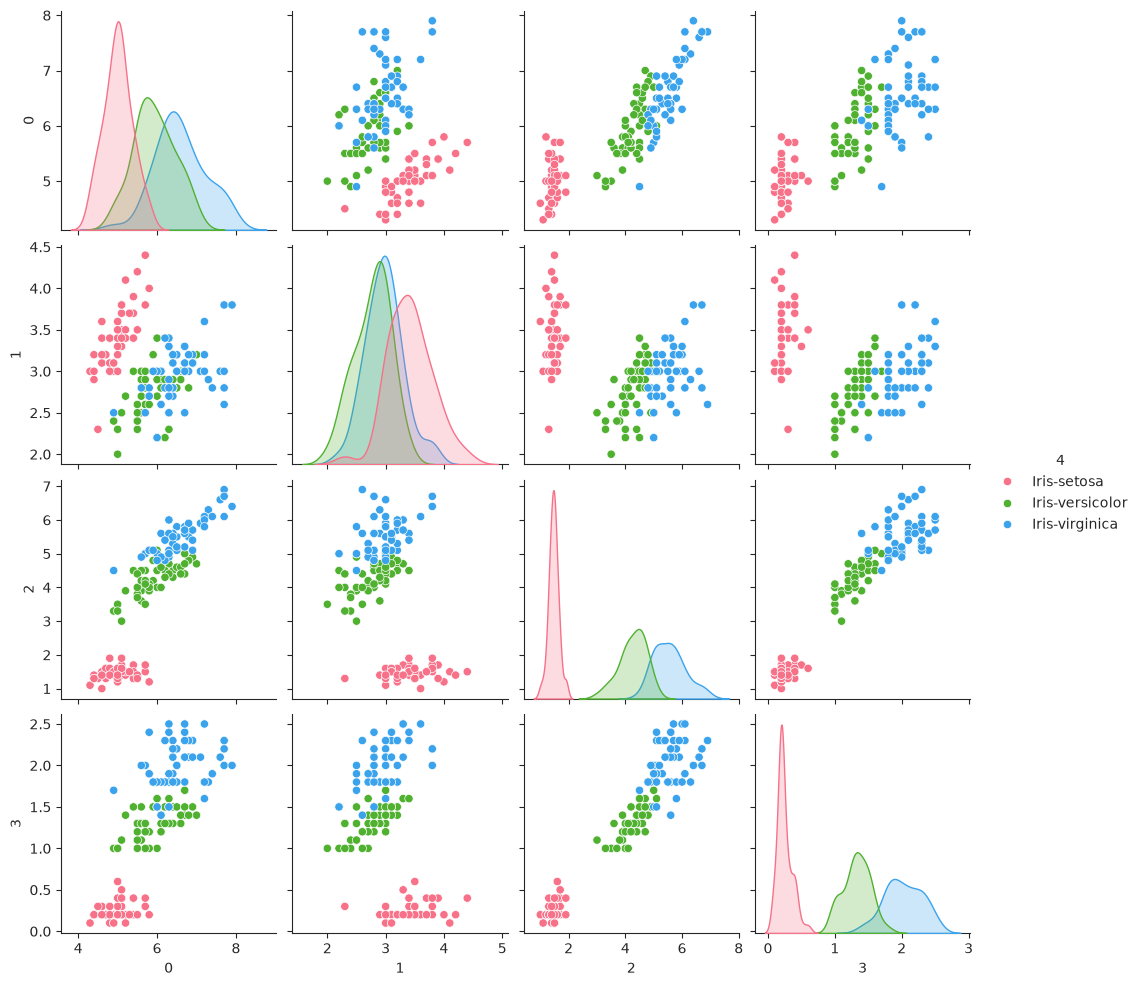

In [19]:
# !pip install seaborn
import seaborn as sns
sns.set_style("ticks")
sns.palplot("husl")
sns.pairplot(dataset, hue=4, palette="husl", diag_kind="kde")

In [20]:
from keras.models import Sequential
from keras.layers import Dense


In [21]:
model = Sequential()
model.add(Dense(3, input_dim=4, activation='relu'))
model.add(Dense(5, activation='relu'))
model.add(Dense(3, activation='softmax'))
#adding of the hidden layer is done now the compilation of the model then fit and train test 
#in the compilation the cross categorical entropy is used because of the multiple class classification and the optimizer is used is adam which is used to 
# it combines the speed of momentum with the stability of adaptive learning rates to train deep neural networks faster and more reliably
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

print(model.get_weights())




[array([[-0.13676447,  0.25206792,  0.21923459],
       [ 0.22919536, -0.01672602, -0.10144675],
       [-0.284796  ,  0.78029656,  0.6627368 ],
       [ 0.72502065, -0.7257151 , -0.5076245 ]], dtype=float32), array([0., 0., 0.], dtype=float32), array([[-0.09082431, -0.57235193, -0.52027607,  0.14472991, -0.7559331 ],
       [-0.49517307,  0.69820267, -0.07398736,  0.00444895, -0.6379051 ],
       [-0.79873097,  0.16974062,  0.44887716,  0.09778357,  0.3342597 ]],
      dtype=float32), array([0., 0., 0., 0., 0.], dtype=float32), array([[-0.5634014 , -0.11852127,  0.43743485],
       [-0.21772891,  0.218543  , -0.5862458 ],
       [-0.6118722 ,  0.12172866,  0.19547862],
       [ 0.13789266, -0.7376341 ,  0.45670098],
       [-0.35908687, -0.05615169,  0.22776383]], dtype=float32), array([0., 0., 0.], dtype=float32)]


/home/heet18/retail-shelf-intelligence/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 3)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53 (212.00 B)

 Trainable params: 53 (212.00 B)

 Non-trainable params: 0 (0.00 B)

In [37]:
model.fit(X_train, y_train, epochs=250, batch_size=8, verbose=1)

Epoch 1/250


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9750 - loss: 0.0567  
Epoch 2/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9750 - loss: 0.0624 
Epoch 3/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9750 - loss: 0.0548 
Epoch 4/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9750 - loss: 0.0572     
Epoch 5/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9750 - loss: 0.0574 
Epoch 6/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9750 - loss: 0.0584 
Epoch 7/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9750 - loss: 0.0577 
Epoch 8/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9750 - loss: 0.0573 
Epoch 9/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9750 - loss: 0.0559 
Epoch 10/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9750 - loss: 0.0585 
Epoch 11/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9750 - loss: 0.0563 
Epoch 12/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accur

In [38]:
print(model.get_weights())


[array([[-0.13494433,  0.7328057 , -0.01008628],
       [ 0.0861578 ,  0.75669765, -0.6439682 ],
       [-0.18520598,  0.45607662,  1.5290995 ],
       [ 1.174693  , -1.3867409 ,  0.7978689 ]], dtype=float32), array([-0.37450835,  1.2377548 , -1.028382  ], dtype=float32), array([[-0.09082431, -1.2095759 , -0.02066295,  1.376955  , -0.7559331 ],
       [-0.49517307,  1.1766853 , -0.13832308, -0.17247133, -0.6379051 ],
       [-0.79873097, -0.3960621 ,  1.7297353 ,  0.52953136,  0.3342597 ]],
      dtype=float32), array([ 0.       ,  1.0770441, -0.8744532, -0.6381843,  0.       ],
      dtype=float32), array([[-0.5634014 , -0.11852127,  0.43743485],
       [ 1.4776417 ,  0.5768624 , -1.2013227 ],
       [-4.737385  , -0.38161132,  1.0631906 ],
       [ 0.4737495 , -1.5855975 ,  1.0517738 ],
       [-0.35908687, -0.05615169,  0.22776383]], dtype=float32), array([ 0.85788083,  0.50717497, -1.2035342 ], dtype=float32)]


In [39]:
score = model.evaluate(X_test, y_test, verbose=0)

In [41]:
print("accuracy: %.2f%%" % (score[1]*100))

accuracy: 100.00%


In [ ]:
#give the probabilities of the classes for each sample in the test set
y_pred = model.predict(X_test)
X_test[1,:], y_pred[1]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


(array([6. , 2.2, 4. , 1. ]),
 array([1.0680421e-07, 9.9947232e-01, 5.2755076e-04], dtype=float32))

In [ ]:
#so the neural network gives the output in the form of probabilities for each class so we need to convert it into the class labels so we will use the argmax function to get the index of the maximum value in each row which will give us the predicted class label for each sample.
y_pred=np.argmax(y_pred, axis=1)
print(y_pred)


[2 1 0 2 0 2 0 1 1 1 2 1 1 1 1 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0]


In [45]:
#now the accuracy of the overall model can be calculated by comparing the predicted class labels with the true class labels in the test set. We can use the accuracy_score function from sklearn.metrics to do this.
from sklearn.metrics import accuracy_score
y_test_labels = np.argmax(y_test, axis=1)
accuracy = accuracy_score(y_test_labels, y_pred)
print("Overall accuracy: %.2f%%" % (accuracy*100))

from sklearn.metrics import classification_report, confusion_matrix
print("Classification Report:\n", classification_report(y_test_labels, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test_labels, y_pred))

Overall accuracy: 100.00%
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00         6

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Confusion Matrix:
 [[11  0  0]
 [ 0 13  0]
 [ 0  0  6]]


In [ ]:
# so the above is the complete code for the neural network model for the iris dataset. The model is trained on the training set and evaluated on the test set. The accuracy of the model is calculated and printed along with the classification report and confusion matrix.